<a href="https://colab.research.google.com/github/akshara-git17/synent-task5-sales-data-analysis-akshara_dave/blob/main/Task5_Sales_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Data Analysis

## Synent Technologies Data Science Internship

### Submitted By:
Akshara Dave

### Objective

The objective of this project is to analyze sales data and identify business trends, customer behavior, regional performance, and profitability insights using data analysis and visualization techniques.

# Business Objectives :

The analysis aims to answer the following questions:

1. Which categories generate the highest sales?
2. Which categories generate the highest profit?
3. Which regions contribute most to revenue?
4. Which regions are least profitable?
5. How do sales change over time?
6. How does profit change over time?
7. Which products generate the highest sales?
8. Who are the most valuable customers?
9. Does discount impact profitability?
10. What relationships exist between numerical variables?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
import pandas as pd

df = pd.read_csv('superstore.csv', encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Dataset Overview

Before performing analysis, it is important to understand the dataset's structure, dimensions, data types, and missing values.

In [3]:
#to get the number of rows(Netflix titles) and columns(features) of the dataset
df.shape

(9994, 21)

In [4]:
#to check the data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
#summary statistics
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
#to show exactly how many missing values each column contains
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [7]:
#checking duplicate records
df.duplicated().sum()

np.int64(0)

### Key Columns for Analysis

The primary columns used in this project are:

- **Sales** for revenue analysis.
- **Profit** for profitability analysis.
- **Category** and **Sub-Category** for product performance analysis.
- **Region** for geographic analysis.
- **Order Date** for monthly trend analysis.
- **Customer Name** for customer performance analysis.
- **Discount** for studying its impact on profitability.

These columns will help answer the business questions defined in the project objectives.

# Data Cleaning

This section focuses on handling missing values, checking duplicates, and preparing the dataset for analysis.

In [8]:
#checking for missing values
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [9]:
#checking for duplicates
df.duplicated().sum()

np.int64(0)

In [10]:
#converting date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [11]:
#create month-year column
df['Month_Year'] = df['Order Date'].dt.to_period('M')

# Analysis 1: Sales by Category

### Business Question

Which product categories generate the highest sales revenue?

### Objective

To identify the categories that contribute the most to overall business revenue.

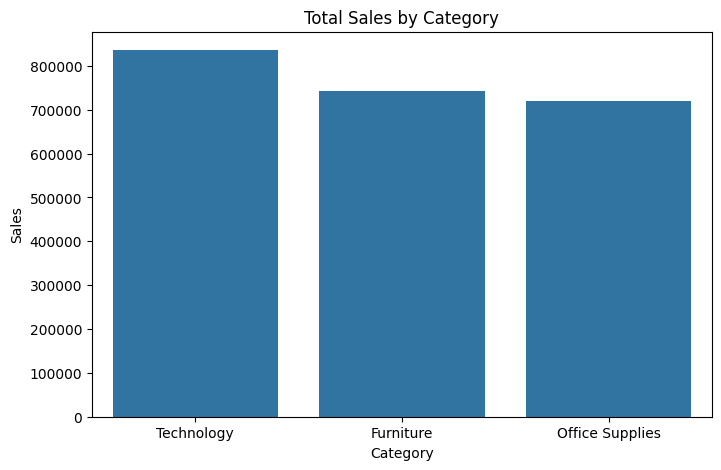

In [12]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')

plt.show()

### Insight

The *'technology'* category with the highest sales contributes significantly to the company's overall revenue and represents a key area of business performance.

# Analysis 2: Profit by Category

### Business Question

Which product categories generate the highest profit?

### Objective

To identify the categories that contribute most to business profitability.

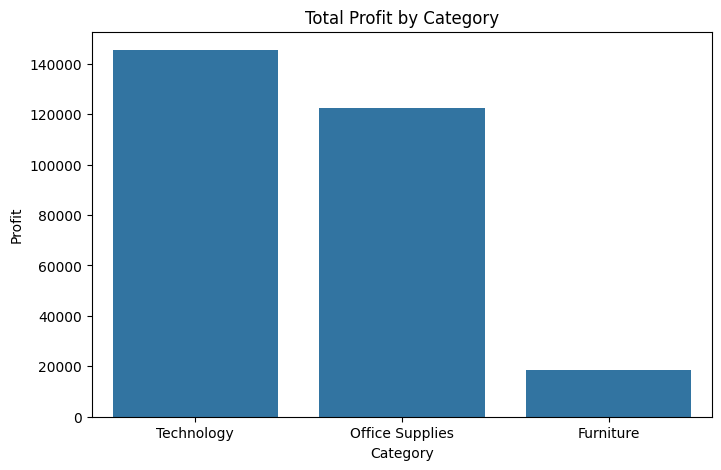

In [13]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_profit.index,
    y=category_profit.values
)

plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')

plt.show()

### Insight

Comparing profit across categories helps identify which categories are not only generating revenue but also delivering strong profitability.Here 'technology' category is producing the higgest profit.

# Analysis 3: Sales by Region

### Business Question

Which regions contribute the most sales?

### Objective

To evaluate regional sales performance and identify high-performing markets.

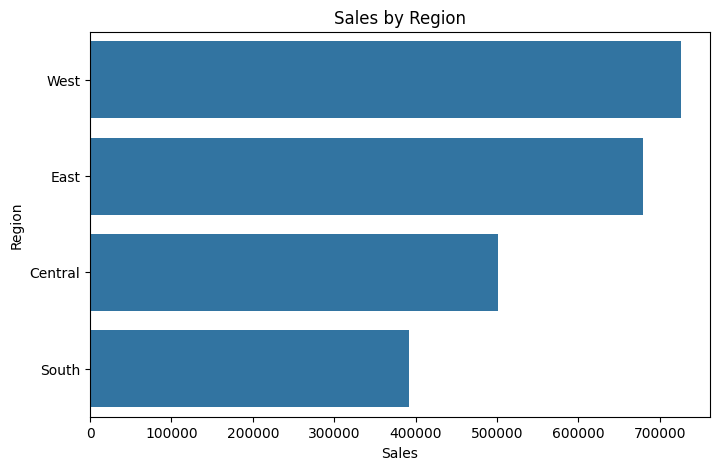

In [14]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.values,
    y=region_sales.index
)

plt.title('Sales by Region')
plt.xlabel('Sales')
plt.ylabel('Region')

plt.show()

###Insight
The West region generated the highest sales, indicating strong market performance, while the South region contributed the lowest sales and may require strategic attention.

# Analysis 4: Profit by Region

### Business Question

Which regions generate the highest profit?

### Objective

To compare profitability across different regions and identify business opportunities.

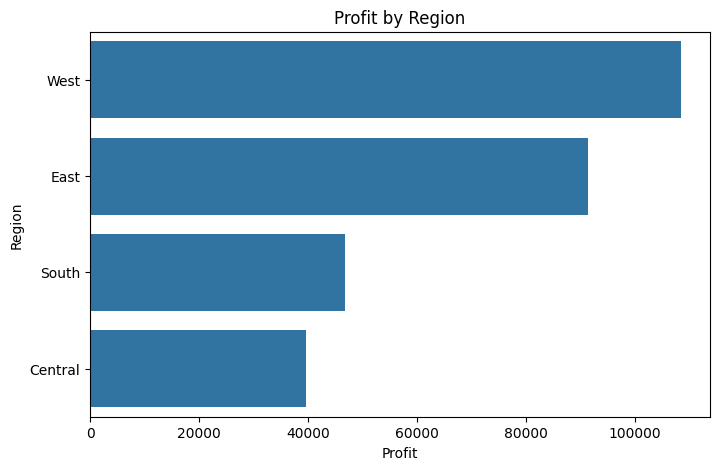

In [15]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=region_profit.values,
    y=region_profit.index
)

plt.title('Profit by Region')
plt.xlabel('Profit')
plt.ylabel('Region')

plt.show()

###Insight
The West region generated the highest profit, while the Central region showed comparatively lower profitability despite contributing significant sales.

# Analysis 5: Monthly Revenue Trend

Revenue trends help evaluate business growth and seasonal patterns over time.

In [16]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Month_Year'] = df['Order Date'].dt.to_period('M')

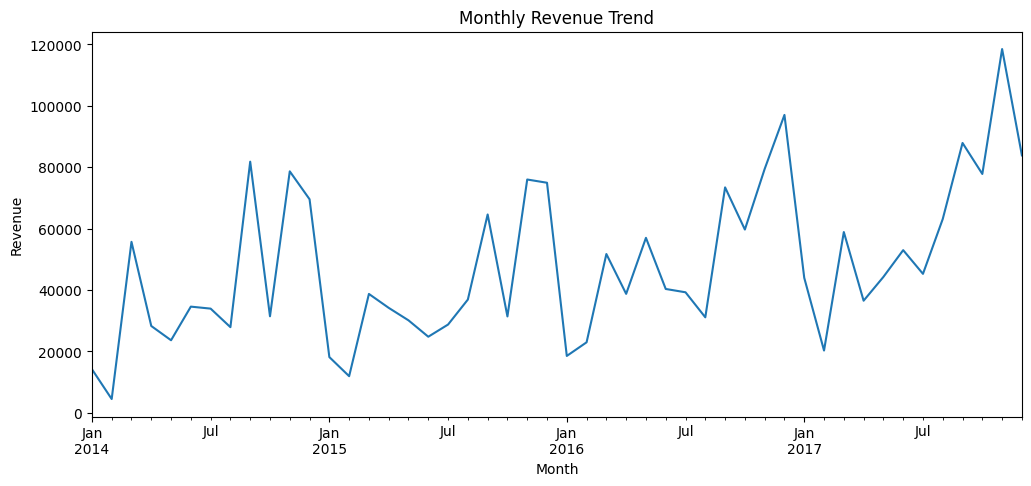

In [17]:
monthly_sales = df.groupby('Month_Year')['Sales'].sum()

plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

###Insight
Revenue generally increased over time, with noticeable fluctuations across months, indicating periods of stronger customer demand and business growth.

# Analysis 6: Monthly Profit Trend

### Business Question

How has business profitability changed over time?

### Objective

To analyze profit trends and identify periods of strong or weak financial performance.

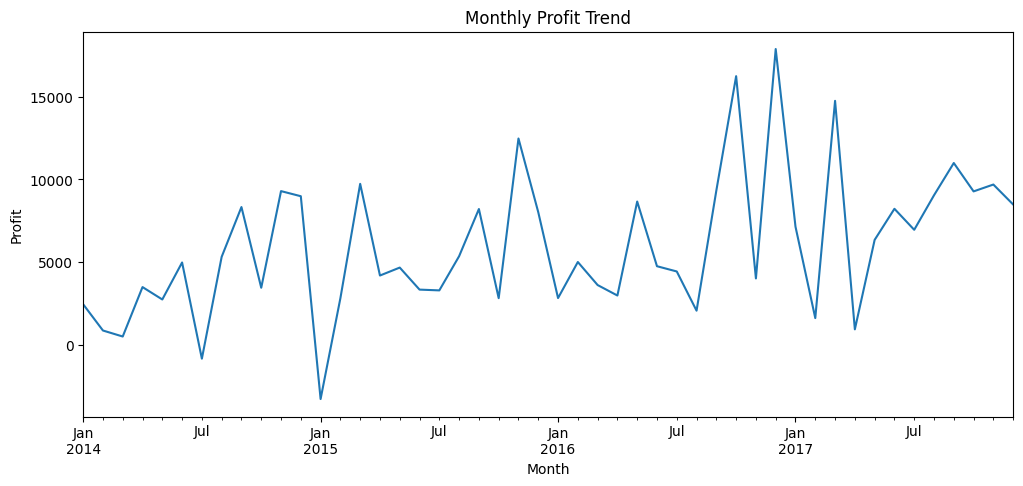

In [18]:
monthly_profit = df.groupby('Month_Year')['Profit'].sum()

plt.figure(figsize=(12,5))

monthly_profit.plot()

plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Profit')

plt.show()

### Insight

The monthly profit trend shows fluctuations in profitability across different months. While the overall profit remains positive for most periods, there are noticeable peaks and declines, indicating variations in business performance. The highest profit levels were observed during late 2016 and early 2017, suggesting periods of strong financial performance. A few months experienced very low or negative profits, highlighting potential challenges such as high discounts, increased costs, or lower sales margins.

# Analysis 7: Top-Selling Products

### Business Question

Which products generate the highest sales revenue?

### Objective

To identify products that contribute the most to overall business revenue.

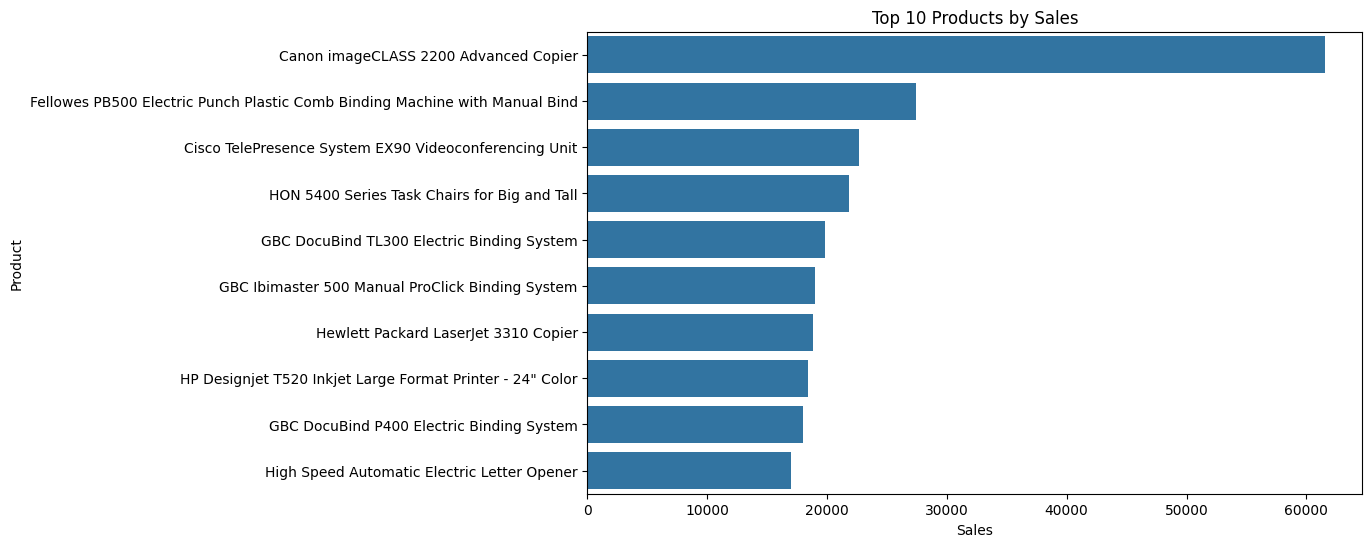

In [19]:
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product')

plt.show()

### Insight

The Canon imageCLASS 2200 Advanced Copier is the highest-selling product by a substantial margin, generating over 60,000 in sales revenue. The gap between the top product and the remaining products suggests that a small number of products contribute significantly to total sales. Focusing on the promotion, availability, and inventory management of these high-performing products can help drive additional revenue growth.

# Analysis 8: Top Customers

### Business Question

Who are the most valuable customers?

### Objective

To identify customers contributing the highest sales revenue.

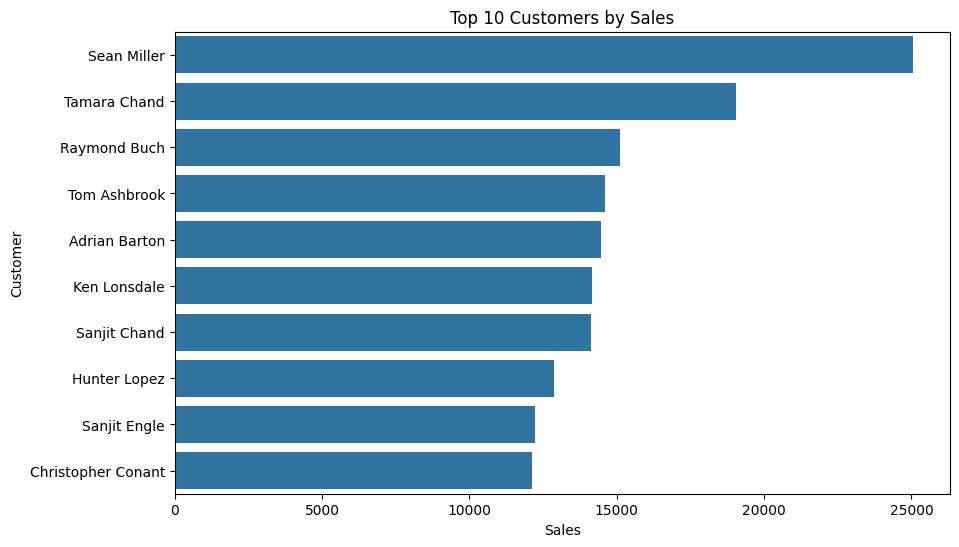

In [20]:
top_customers = (
    df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index
)

plt.title('Top 10 Customers by Sales')
plt.xlabel('Sales')
plt.ylabel('Customer')

plt.show()

### Insight

Sean Miller is the highest-value customer, generating approximately 25,000 in sales revenue, followed by Tamara Chand. The gap between the top customers and the rest suggests that a small group of customers contributes significantly to overall sales. Maintaining strong relationships with these high-value customers can improve customer retention and support future revenue growth.

# Analysis 9: Discount vs Profit

### Business Question

Does offering higher discounts impact profitability?

### Objective

To examine the relationship between discount levels and profit.

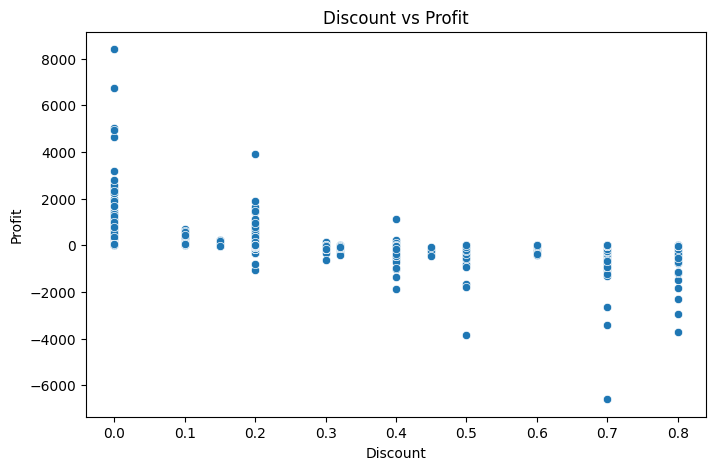

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit'
)

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.show()

### Insight

The scatter plot shows a clear pattern where higher discount levels are generally associated with lower profits. Orders with little or no discount tend to generate higher profits, while heavily discounted orders often result in reduced or even negative profits. This suggests that excessive discounting may negatively impact the company's profitability and should be carefully managed.

# Analysis 10: Correlation Analysis

### Business Question

What relationships exist among the numerical variables in the dataset?

### Objective

To identify correlations between sales, profit, quantity, and discount.

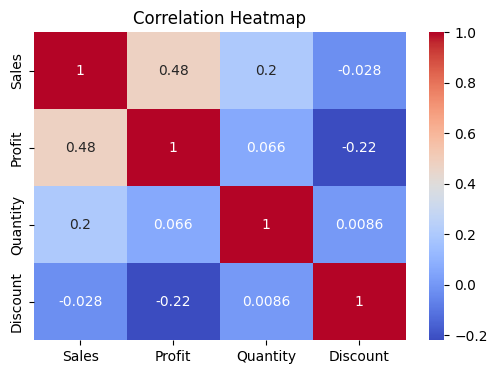

In [22]:
numeric_df = df[['Sales', 'Profit', 'Quantity', 'Discount']]

plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

### Insight

The correlation analysis shows a moderate positive relationship (0.48) between Sales and Profit, indicating that higher sales generally contribute to higher profits. Quantity has a weak positive relationship with both Sales and Profit, suggesting that selling more units does not always guarantee significantly higher profitability. Discount has a negative correlation (-0.22) with Profit, reinforcing the earlier observation that higher discounts tend to reduce profitability.